<a href="https://colab.research.google.com/github/vanessamutimaamba-stack/Practice_code/blob/main/ALY6040_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv('/content/Bank Customer Churn Prediction 2.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
df.describe()

print("\nMissing Values:")
df.isnull().sum()

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# Examine target variable distribution
print("\nChurn Distribution:")
print(df['churn'].value_counts())

# Drop irrelevant columns
df.drop('customer_id', axis=1, inplace=True)
print("\n'customer_id' column dropped.")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB

Descriptive Statistics:

Missing Values:

Categorical Columns: ['country', 'gender']
Numerical Columns: ['customer_id', 'credit_score', 'age', 'tenure', 

In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Separate target variable 'churn' into y and features into X
X = df.drop('churn', axis=1)
y = df['churn']

# 2. Identify categorical and numerical features from X
# 'customer_id' has already been dropped from df, so it's not in X.
# 'churn' is now y, so it's not in X.

categorical_features = ['country', 'gender'] # Based on previous identification
numerical_features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

# 3. Apply one-hot encoding to categorical features
X_categorical = pd.get_dummies(X[categorical_features], drop_first=True)

# 4. Initialize StandardScaler
scaler = StandardScaler()

# 5. Apply standard scaling to numerical features in X
X_numerical_scaled = scaler.fit_transform(X[numerical_features])
X_numerical_scaled = pd.DataFrame(X_numerical_scaled, columns=numerical_features, index=X.index)

# 6. Concatenate one-hot encoded categorical features and scaled numerical features
X_processed = pd.concat([X_numerical_scaled, X_categorical], axis=1)

print("Shape of X_processed:", X_processed.shape)
print("First 5 rows of X_processed:")
print(X_processed.head())

Shape of X_processed: (10000, 11)
First 5 rows of X_processed:
   credit_score       age    tenure   balance  products_number  credit_card  \
0     -0.326221  0.293517 -1.041760 -1.225848        -0.911583     0.646092   
1     -0.440036  0.198164 -1.387538  0.117350        -0.911583    -1.547768   
2     -1.536794  0.293517  1.032908  1.333053         2.527057     0.646092   
3      0.501521  0.007457 -1.387538 -1.225848         0.807737    -1.547768   
4      2.063884  0.388871 -1.041760  0.785728        -0.911583     0.646092   

   active_member  estimated_salary  country_Germany  country_Spain  \
0       0.970243          0.021886            False          False   
1       0.970243          0.216534            False           True   
2      -1.030670          0.240687            False          False   
3      -1.030670         -0.108918            False          False   
4       0.970243         -0.365276            False           True   

   gender_Male  
0        False  
1      

In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 11)
Shape of X_test: (2000, 11)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [5]:
from sklearn.linear_model import LogisticRegression

# Initialize and train a logistic regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for better convergence
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


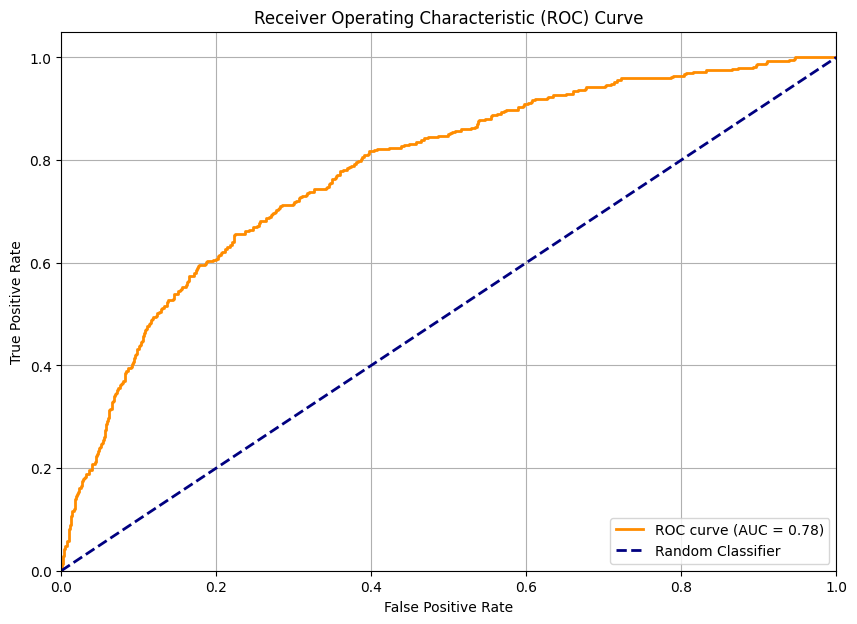

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities for the positive class (churn=1)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Calculate False Positive Rate (fpr), True Positive Rate (tpr), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Initialize empty lists to store metrics and thresholds
thresholds = np.arange(0.0, 1.0, 0.05).tolist()
accuracies = []
precisions = []
recalls = []
f1_scores = []

# 2. Loop through each threshold
for threshold in thresholds:
    # a. Convert predicted probabilities into binary predictions
    y_pred_thresholded = (y_pred_proba >= threshold).astype(int)

    # b. Calculate metrics
    accuracies.append(accuracy_score(y_test, y_pred_thresholded))
    precisions.append(precision_score(y_test, y_pred_thresholded, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_thresholded, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_thresholded, zero_division=0))

# 3. Print a sample of the collected metrics
print("Sample of metrics for different thresholds:")
print("Threshold | Accuracy | Precision | Recall | F1-Score")
print("---------------------------------------------------")
for i in range(min(5, len(thresholds))):
    print(f"{thresholds[i]:<9.2f} | {accuracies[i]:<8.4f} | {precisions[i]:<9.4f} | {recalls[i]:<6.4f} | {f1_scores[i]:<8.4f}")

# You can also store these in a DataFrame for easier analysis if needed
metrics_df = pd.DataFrame({
    'Threshold': thresholds,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})
print("\nMetrics stored in 'metrics_df' DataFrame.")


Sample of metrics for different thresholds:
Threshold | Accuracy | Precision | Recall | F1-Score
---------------------------------------------------
0.00      | 0.1965   | 0.1965    | 1.0000 | 0.3285  
0.05      | 0.2890   | 0.2140    | 0.9796 | 0.3513  
0.10      | 0.4725   | 0.2619    | 0.9262 | 0.4083  
0.15      | 0.6110   | 0.3144    | 0.8295 | 0.4559  
0.20      | 0.7030   | 0.3683    | 0.7150 | 0.4862  

Metrics stored in 'metrics_df' DataFrame.


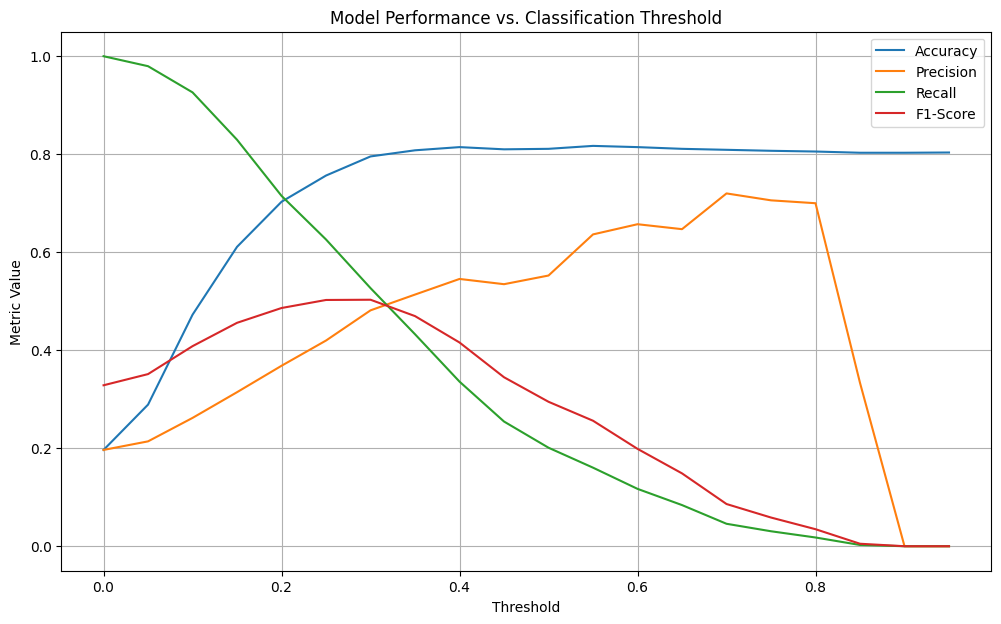

In [9]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
plt.figure(figsize=(12, 7))

# Plot each metric against the threshold
plt.plot(metrics_df['Threshold'], metrics_df['Accuracy'], label='Accuracy')
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], label='Precision')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], label='Recall')
plt.plot(metrics_df['Threshold'], metrics_df['F1-Score'], label='F1-Score')

# Add title and labels
plt.title('Model Performance vs. Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')

# Add legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()